<a href="https://colab.research.google.com/github/pmatkowska94/MSC_Data_Science/blob/main/Pilot_Normalize%2BRNN_improved.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving test_df.csv to test_df.csv
Saving train_df.csv to train_df.csv
Saving val_df.csv to val_df.csv


In [ ]:
train_df = pd.read_csv('train_df.csv')
test_df = pd.read_csv('test_df.csv')
val_df = pd.read_csv('val_df.csv')

In [ ]:
for df in [train_df, val_df, test_df]:
  df['group_volume'] = df['volume']
  df['group_clone'] = df['clone_id']

train_df.head()

,p_id,r_id,clone_id,time,vcd,volume,agitation,p_v,vvm,impeller_d,tip_speed,aspect_r,reynolds,group_volume,group_clone
0,1,1,1,-0.014656,0.68,10.0,144.0,100.0,0.07,13.6,1.03,1.5,44390.0,10.0,1
1,1,1,1,0.996618,1.45,10.0,144.0,100.0,0.07,13.6,1.03,1.5,44390.0,10.0,1
2,1,1,1,1.978579,3.75,10.0,144.0,100.0,0.07,13.6,1.03,1.5,44390.0,10.0,1
3,1,1,1,2.989853,7.77,10.0,144.0,100.0,0.07,13.6,1.03,1.5,44390.0,10.0,1
4,1,1,1,3.986471,12.52,10.0,144.0,100.0,0.07,13.6,1.03,1.5,44390.0,10.0,1


In [ ]:
drop_cols = ['impeller_d', 'agitation']
train_df = train_df.drop(columns=drop_cols)
val_df = val_df.drop(columns=drop_cols)
test_df = test_df.drop(columns=drop_cols)

train_df.head()

,p_id,r_id,clone_id,time,vcd,volume,p_v,vvm,tip_speed,aspect_r,reynolds,group_volume,group_clone
0,1,1,1,-0.014656,0.68,10.0,100.0,0.07,1.03,1.5,44390.0,10.0,1
1,1,1,1,0.996618,1.45,10.0,100.0,0.07,1.03,1.5,44390.0,10.0,1
2,1,1,1,1.978579,3.75,10.0,100.0,0.07,1.03,1.5,44390.0,10.0,1
3,1,1,1,2.989853,7.77,10.0,100.0,0.07,1.03,1.5,44390.0,10.0,1
4,1,1,1,3.986471,12.52,10.0,100.0,0.07,1.03,1.5,44390.0,10.0,1


In [ ]:
from sklearn.preprocessing import OrdinalEncoder

enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
enc.fit(train_df[['clone_id']])

for df in [train_df, val_df, test_df]:
    df['clone_id'] = enc.transform(df[['clone_id']])
    df['clone_id'] = df['clone_id'].astype(int)

In [ ]:
np.random.seed(42)

def augment_sequence (df_group, noise = 0.05):
  aug_df = df_group.copy()
  for col in ['p_v', 'vvm', 'tip_speed', 'reynolds']:
    aug_df[col] += aug_df[col] * np.random.uniform(-noise, noise)
  return aug_df

In [ ]:
train_df['group_id'] = train_df.groupby(['p_id', 'r_id', 'group_clone', 'group_volume']).ngroup()

train_aug = []

for group_id, df_group in train_df.groupby('group_id'):
    for i in range(2):
        augmented = augment_sequence(df_group)
        augmented['group_id'] = f'{group_id}_aug{i}'
        train_aug.append(augmented)
train_df['group_id'] = train_df['group_id'].astype(str)
train_aug = pd.concat([train_df] + train_aug, ignore_index=True)

train_aug.head()

,p_id,r_id,clone_id,time,vcd,volume,p_v,vvm,tip_speed,aspect_r,reynolds,group_volume,group_clone,group_id
0,1,1,0,-0.014656,0.68,10.0,100.0,0.07,1.03,1.5,44390.0,10.0,1,0
1,1,1,0,0.996618,1.45,10.0,100.0,0.07,1.03,1.5,44390.0,10.0,1,0
2,1,1,0,1.978579,3.75,10.0,100.0,0.07,1.03,1.5,44390.0,10.0,1,0
3,1,1,0,2.989853,7.77,10.0,100.0,0.07,1.03,1.5,44390.0,10.0,1,0
4,1,1,0,3.986471,12.52,10.0,100.0,0.07,1.03,1.5,44390.0,10.0,1,0


In [ ]:
train_aug['group_id'].nunique()

84

In [ ]:
def truncate_to_exponential_phase(df, group_col):
    truncated = []
    for _, group in df.groupby(group_cols):
        peak_idx = group['vcd'].idxmax()
        peak_time = group.loc[peak_idx, 'time']
        buffer_time = peak_time + 3

        exp_phase = group[group['time'] <= buffer_time]
        truncated.append(exp_phase)
    return pd.concat(truncated)

In [ ]:
group_cols = ['p_id', 'r_id', 'group_clone', 'group_volume', 'group_id']
train_aug = truncate_to_exponential_phase(train_aug, group_cols)

val_df['group_id'] = 1
test_df['group_id'] = 1

val_df = truncate_to_exponential_phase(val_df, group_cols)
test_df = truncate_to_exponential_phase(test_df, group_cols)

I will crerate here dataset contai9ning CHo and iPSC data for scaling.

In [ ]:
uploaded = files.upload()

Saving train_aug_ipsc_scaling.csv to train_aug_ipsc_scaling.csv


In [ ]:
train_aug_ipsc_scaling = pd.read_csv('train_aug_ipsc_scaling.csv')

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import joblib

num_cols = ['time', 'vcd', 'volume', 'p_v', 'vvm', 'tip_speed', 'aspect_r', 'reynolds']

scaling_df = pd.concat([train_aug[num_cols], train_aug_ipsc_scaling[num_cols]], ignore_index=True)

scaler = MinMaxScaler(feature_range=(-1, 1))
scaler.fit(scaling_df)

train_aug[num_cols] = scaler.transform(train_aug[num_cols])

joblib.dump(scaler, 'scaler_combined_cho_ipsc.pkl')

print("train_aug range:")
print(train_aug[num_cols].agg(['min', 'max']))
print("train_aug_ipsc_scaling range:")
print(train_aug_ipsc_scaling[num_cols].agg(['min', 'max']))

train_aug range:
     time       vcd  volume       p_v  vvm  tip_speed  aspect_r  reynolds
min  -1.0 -0.980985    -1.0 -0.926839 -1.0  -0.701467      -1.0 -0.990456
max   1.0  1.000000     1.0  1.000000  1.0   1.000000       1.0  1.000000
train_aug_ipsc_scaling range:
         time    vcd  volume       p_v       vvm  tip_speed  aspect_r  \
min   0.00000  0.031   0.100  0.700516  0.000000   0.129204      1.51   
max  11.93375  8.700   0.415  1.324353  0.015312   0.200049      1.51   

        reynolds  
min  1633.412010  
max  2619.948362  


In [ ]:
files.download('scaler_combined_cho_ipsc.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
scaler = joblib.load("scaler_combined_cho_ipsc.pkl")

test_df[num_cols] = scaler.transform(test_df[num_cols])

In [ ]:
test_df.head()

,p_id,r_id,clone_id,time,vcd,volume,p_v,vvm,tip_speed,aspect_r,reynolds,group_volume,group_clone,group_id
0,3,1,-1,-0.997294,-0.956023,-0.999765,-0.922879,0.093568,-0.693892,0.056604,-0.984783,0.25,4,1
1,3,1,-1,-0.831363,-0.933264,-0.999765,-0.922879,0.093568,-0.693892,0.056604,-0.984783,0.25,4,1
2,3,1,-1,-0.499136,-0.830481,-0.999765,-0.922879,0.093568,-0.693892,0.056604,-0.984783,0.25,4,1
3,3,1,-1,-0.332739,-0.726963,-0.999765,-0.922879,0.093568,-0.693892,0.056604,-0.984783,0.25,4,1
4,3,1,-1,0.000254,-0.486156,-0.999765,-0.922879,0.093568,-0.693892,0.056604,-0.984783,0.25,4,1


In [ ]:
val_df[num_cols] = scaler.transform(val_df[num_cols])

In [ ]:
val_df.head()

,p_id,r_id,clone_id,time,vcd,volume,p_v,vvm,tip_speed,aspect_r,reynolds,group_volume,group_clone,group_id
0,4,1,-1,-0.997560,-0.965362,-0.997015,-0.866038,-1.0,-0.098795,0.056604,-0.863665,3.0,5,1
1,4,1,-1,-0.831097,-0.916144,-0.997015,-0.866038,-1.0,-0.098795,0.056604,-0.863665,3.0,5,1
2,4,1,-1,-0.688414,-0.879231,-0.997015,-0.866038,-1.0,-0.098795,0.056604,-0.863665,3.0,5,1
3,4,1,-1,-0.498170,-0.694664,-0.997015,-0.866038,-1.0,-0.098795,0.056604,-0.863665,3.0,5,1
4,4,1,-1,-0.355487,-0.559314,-0.997015,-0.866038,-1.0,-0.098795,0.056604,-0.863665,3.0,5,1


In [ ]:
feature_cols = [col for col in train_aug.columns if col not in group_cols]
train_sort = train_aug.sort_values(group_cols + ['time'])
sequences = (
    train_sort.groupby(group_cols)[feature_cols]
    .apply(lambda x: x.values)
    .tolist()
)

print(len(sequences))
print(sequences[0].shape)

84
(12, 9)


In [ ]:
for i, seq in enumerate(sequences):
    print(f"{i} = {seq.shape}")

0 = (12, 9)
1 = (12, 9)
2 = (12, 9)
3 = (10, 9)
4 = (10, 9)
5 = (10, 9)
6 = (10, 9)
7 = (10, 9)
8 = (10, 9)
9 = (10, 9)
10 = (10, 9)
11 = (10, 9)
12 = (10, 9)
13 = (10, 9)
14 = (10, 9)
15 = (10, 9)
16 = (10, 9)
17 = (10, 9)
18 = (11, 9)
19 = (11, 9)
20 = (11, 9)
21 = (10, 9)
22 = (10, 9)
23 = (10, 9)
24 = (11, 9)
25 = (11, 9)
26 = (11, 9)
27 = (11, 9)
28 = (11, 9)
29 = (11, 9)
30 = (11, 9)
31 = (11, 9)
32 = (11, 9)
33 = (11, 9)
34 = (11, 9)
35 = (11, 9)
36 = (14, 9)
37 = (14, 9)
38 = (14, 9)
39 = (11, 9)
40 = (11, 9)
41 = (11, 9)
42 = (11, 9)
43 = (11, 9)
44 = (11, 9)
45 = (10, 9)
46 = (10, 9)
47 = (10, 9)
48 = (12, 9)
49 = (12, 9)
50 = (12, 9)
51 = (10, 9)
52 = (10, 9)
53 = (10, 9)
54 = (11, 9)
55 = (11, 9)
56 = (11, 9)
57 = (11, 9)
58 = (11, 9)
59 = (11, 9)
60 = (10, 9)
61 = (10, 9)
62 = (10, 9)
63 = (12, 9)
64 = (12, 9)
65 = (12, 9)
66 = (12, 9)
67 = (12, 9)
68 = (12, 9)
69 = (10, 9)
70 = (10, 9)
71 = (10, 9)
72 = (12, 9)
73 = (12, 9)
74 = (12, 9)
75 = (11, 9)
76 = (11, 9)
77 = (11,

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
pad = -2.0
padded_sequences = pad_sequences(
    sequences,
    maxlen=12,
    dtype='float32',
    padding='post',
    value=pad)
print(padded_sequences.shape)

(84, 12, 9)


In [ ]:
test_sort = test_df.sort_values(group_cols + ['time'])

test_sequences = (
    test_sort.groupby(group_cols)[feature_cols]
    .apply(lambda x: x.values)
    .tolist()
)

print(len(test_sequences))

8


In [ ]:
padded_test_sequences = pad_sequences(
    test_sequences,
    maxlen=12,
    dtype='float32',
    padding='post',
    value=pad)
print(padded_test_sequences.shape)

(8, 12, 9)


In [ ]:
val_sort = val_df.sort_values(group_cols + ['time'])
val_sequences = (
    val_sort.groupby(group_cols)[feature_cols]
    .apply(lambda x: x.values)
    .tolist()
)

print(len(val_sequences))

padded_val_sequences = pad_sequences(
    val_sequences,
    maxlen=12,
    dtype='float32',
    padding='post',
    value=pad)
print(padded_val_sequences.shape)

7
(7, 12, 9)


In [ ]:
vcd_idx = feature_cols.index('vcd')

X_train = np.delete(padded_sequences, vcd_idx, axis=2)
y_train = padded_sequences[:, :, vcd_idx]


X_val = np.delete(padded_val_sequences, vcd_idx, axis=2)
y_val = padded_val_sequences[:, :, vcd_idx]


X_test = np.delete(padded_test_sequences, vcd_idx, axis=2)
y_test = padded_test_sequences[:, :, vcd_idx]


In [ ]:
y_train.shape

(84, 12)

In [ ]:
print(y_train[0])

[-0.9523525  -0.8958216  -0.726963   -0.43182752 -0.08309779  0.23186022
  0.36107376  0.44403473  0.45064223  0.3779596   0.30821368  0.31482118]


In [ ]:
import tensorflow as tf
y_train = tf.expand_dims(y_train, axis=-1)
y_val = tf.expand_dims(y_val, axis=-1)
y_test = tf.expand_dims(y_test, axis=-1)

In [ ]:
y_test.shape

TensorShape([8, 12, 1])

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import regularizers


timesteps = X_train.shape[1]
n_features = X_train.shape[2]

model = models.Sequential([
    layers.Masking(mask_value=-2.0, input_shape=(timesteps, n_features)),

    layers.Bidirectional(layers.LSTM(64, return_sequences=True, dropout=0.5, recurrent_dropout=0.5)),
    layers.LayerNormalization(),
    layers.Dropout(0.5),

    layers.Bidirectional(layers.LSTM(32, return_sequences=True, dropout=0.5, recurrent_dropout=0.5)),
    layers.LayerNormalization(),
    layers.Dropout(0.4),

    layers.Dense(64, activation='tanh', kernel_regularizer=regularizers.l2(0.01)),
    layers.Dense(1, activation='tanh')
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

early_stop = EarlyStopping(patience=30, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=8,
    callbacks=[early_stop]
)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/masking.py:47: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 25s 377ms/step - loss: 1.3512 - mae: 0.8157 - val_loss: 1.6150 - val_mae: 1.0697
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 119ms/step - loss: 1.1556 - mae: 0.6973 - val_loss: 1.3709 - val_mae: 0.9979
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - loss: 0.9844 - mae: 0.6251 - val_loss: 1.1068 - val_mae: 0.9256
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - loss: 0.8797 - mae: 0.5784 - val_loss: 1.0447 - val_mae: 0.9325
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 103ms/step - loss: 0.8467 - mae: 0.5734 - val_loss: 1.0235 - val_mae: 0.9197
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step - loss: 0.8435 - mae: 0.5883 - val_loss: 0.9085 - val_mae: 0.8845
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - loss: 0.8219 - mae: 0.5982 - val_loss: 0.9742 - val_mae: 0.9287
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - loss: 0.7789 - mae: 0.5667 - val_loss: 0.7927 - val_mae: 0.8193
Epoch 9/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/ste

Text(0.5, 1.0, 'Loss over Epochs')

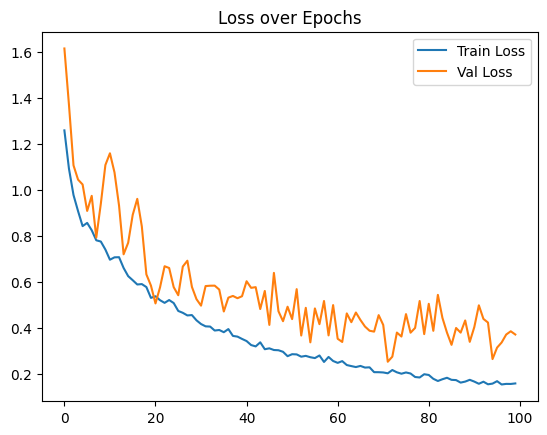

In [ ]:
hist = pd.DataFrame(model.history.history)
plt.plot(hist["loss"], label="Train Loss")
plt.plot(hist["val_loss"], label="Val Loss")
plt.legend()
plt.title("Loss over Epochs")

In [ ]:
print(X_test.shape)
print(y_test.shape)

(8, 12, 8)
(8, 12, 1)


In [ ]:
model.evaluate(X_test, y_test)
predicted_vcd = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.1317 - mae: 0.2539
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


In [ ]:
predicted_vcd = predicted_vcd.squeeze(-1)
y_test = y_test.numpy().squeeze(-1) if isinstance(y_test, tf.Tensor) else y_test.squeeze(-1)

In [ ]:
scaler = joblib.load('scaler_combined_cho_ipsc.pkl')

n_samples, time_steps = predicted_vcd.shape
vcd_idx = list(scaler.feature_names_in_).index('vcd')

flat_pred = predicted_vcd.flatten()
flat_true = y_test.flatten()

dummy_pred = np.zeros((n_samples * time_steps, len(scaler.feature_names_in_)))
dummy_true = np.zeros_like(dummy_pred)

dummy_pred[:, vcd_idx] = flat_pred
dummy_true[:, vcd_idx] = flat_true

inv_pred = scaler.inverse_transform(dummy_pred)[:, vcd_idx]
inv_true = scaler.inverse_transform(dummy_true)[:, vcd_idx]

vcd_pred_original = inv_pred.reshape(n_samples, time_steps)
vcd_true_original = inv_true.reshape(n_samples, time_steps)

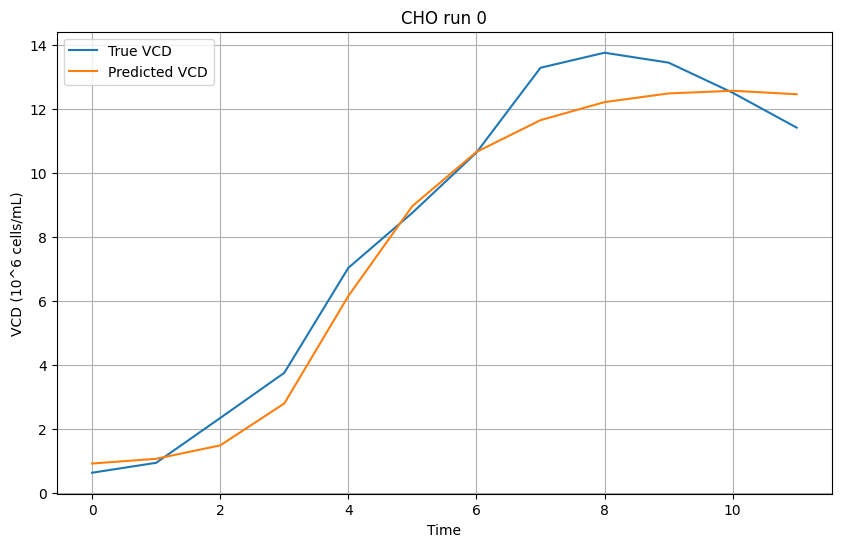

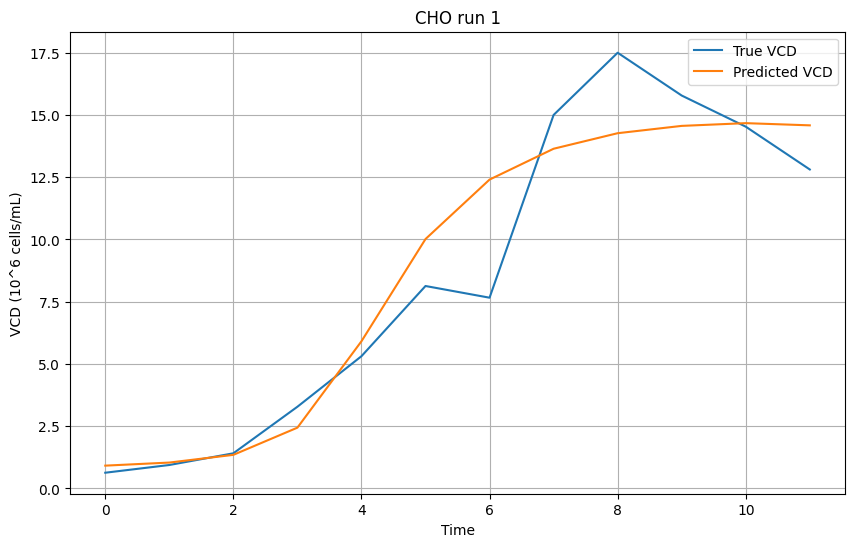

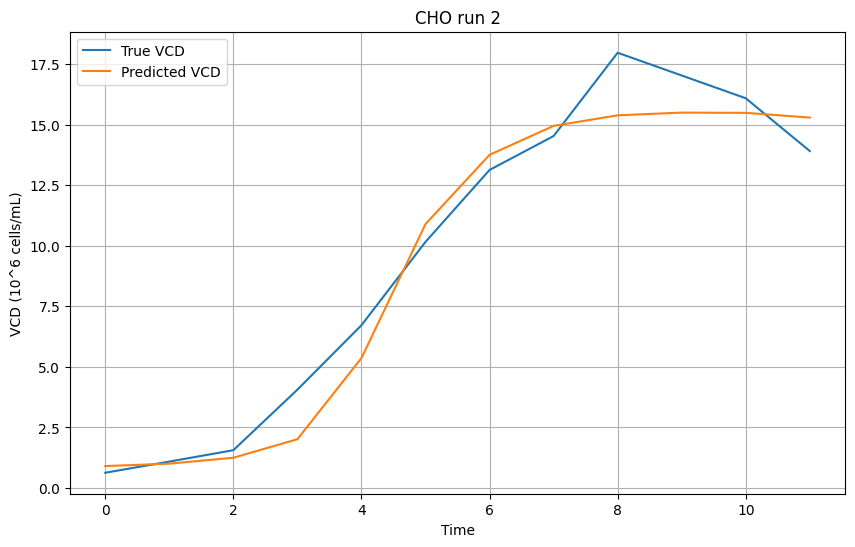

In [ ]:
for i in range(min(3, n_samples)):
    plt.figure(figsize=(10, 6))
    plt.plot(vcd_true_original[i], label='True VCD')
    plt.plot(vcd_pred_original[i], label='Predicted VCD')
    plt.title(f'CHO run {i}')
    plt.xlabel('Time')
    plt.ylabel('VCD (10^6 cells/mL)')
    plt.legend()
    plt.grid(True)

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

mask = y_test != -2.0

masked_true = vcd_true_original[mask]
masked_pred = vcd_pred_original[mask]

mse = mean_squared_error(masked_true, masked_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(masked_true, masked_pred)

print(f"Test RMSE= {rmse:.2f} 10^6 cells/mL")
print(f"Test MAE= {mae:.2f} 10^6 cells/mL")

Test RMSE= 3.01 10^6 cells/mL
Test MAE= 2.04 10^6 cells/mL


In [ ]:
rmse_p = (rmse / vcd_true_original.max()) * 100
mae_p = (mae / vcd_true_original.max()) * 100

print(f"RMSE = {rmse_p:.1f}% of the VCD max in test set.")
print(f"MAE = {mae_p:.1f}% of the VCD max in test set.")

RMSE = 12.1% of the VCD max in test set.
MAE = 8.2% of the VCD max in test set.


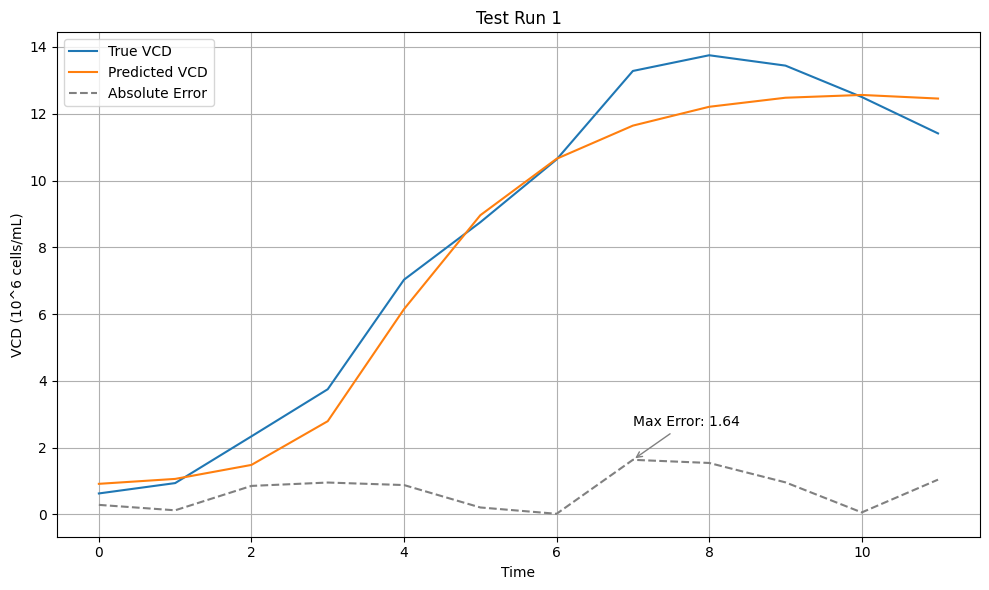

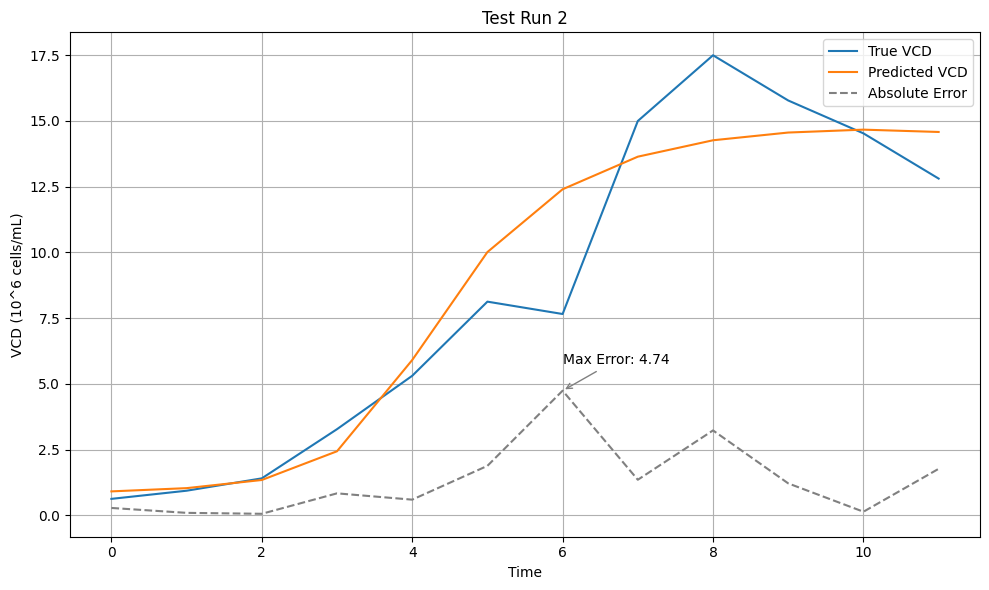

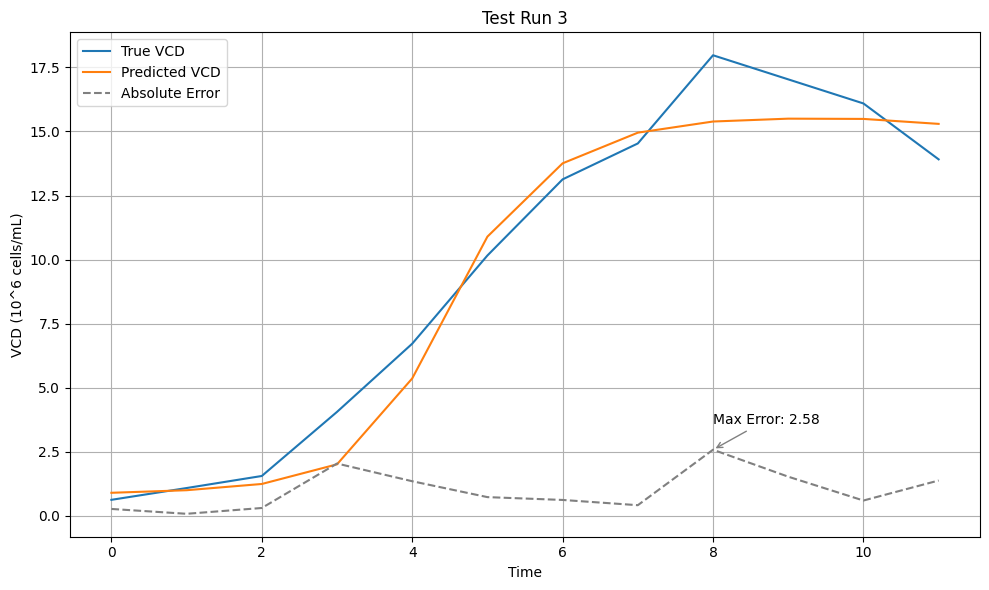

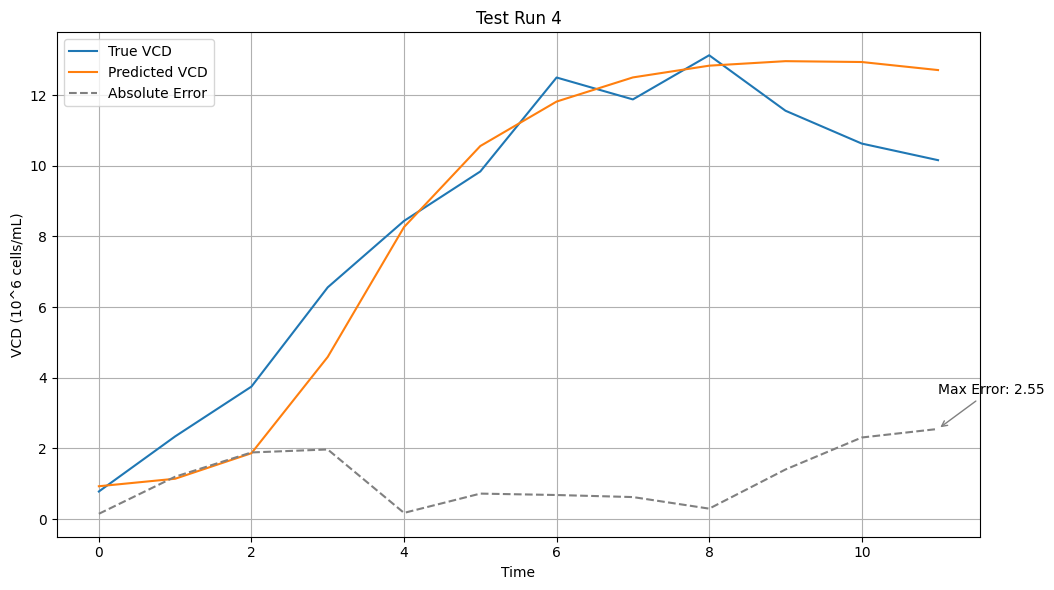

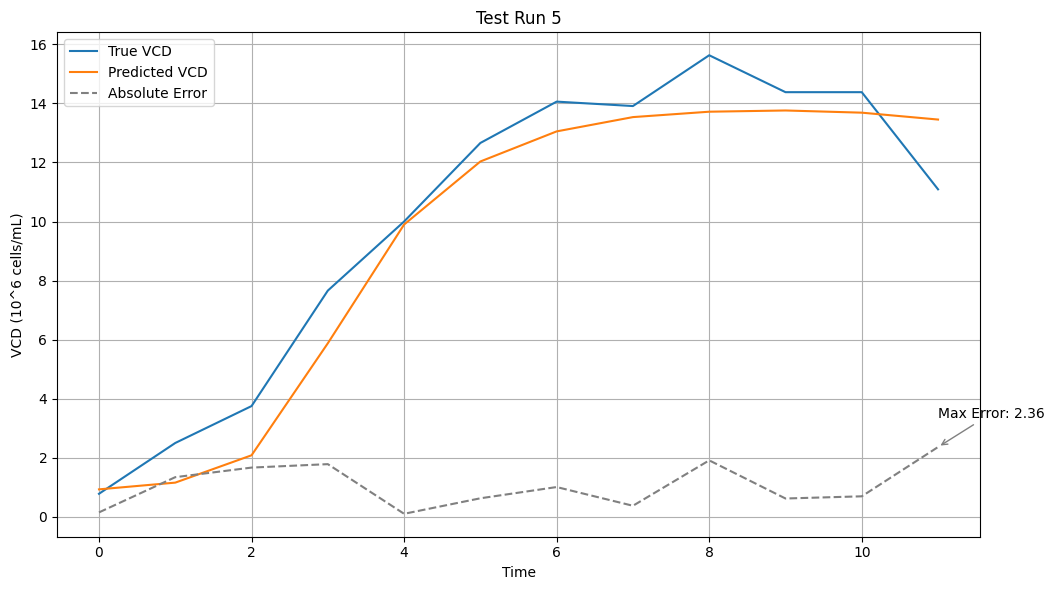

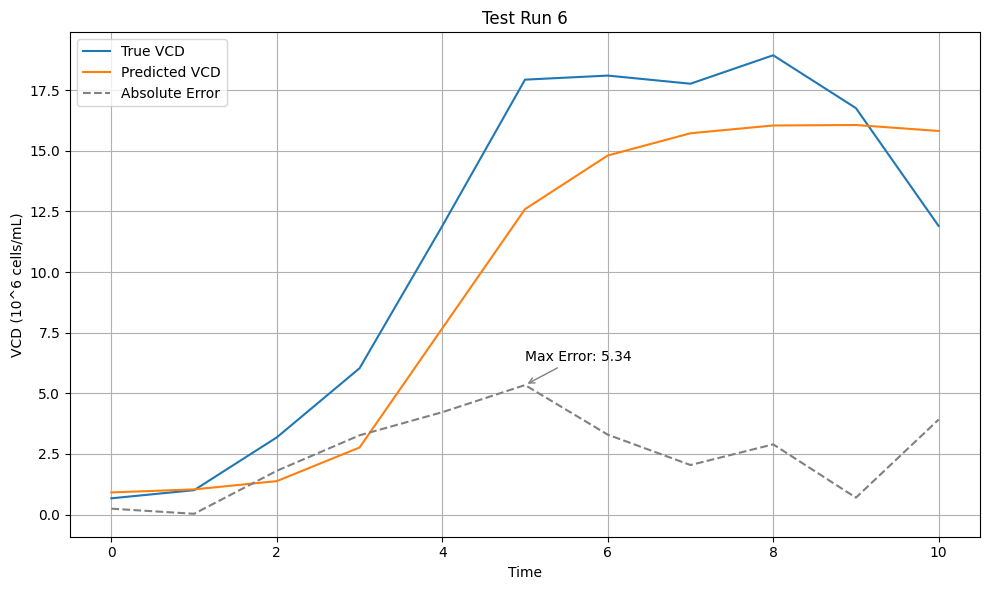

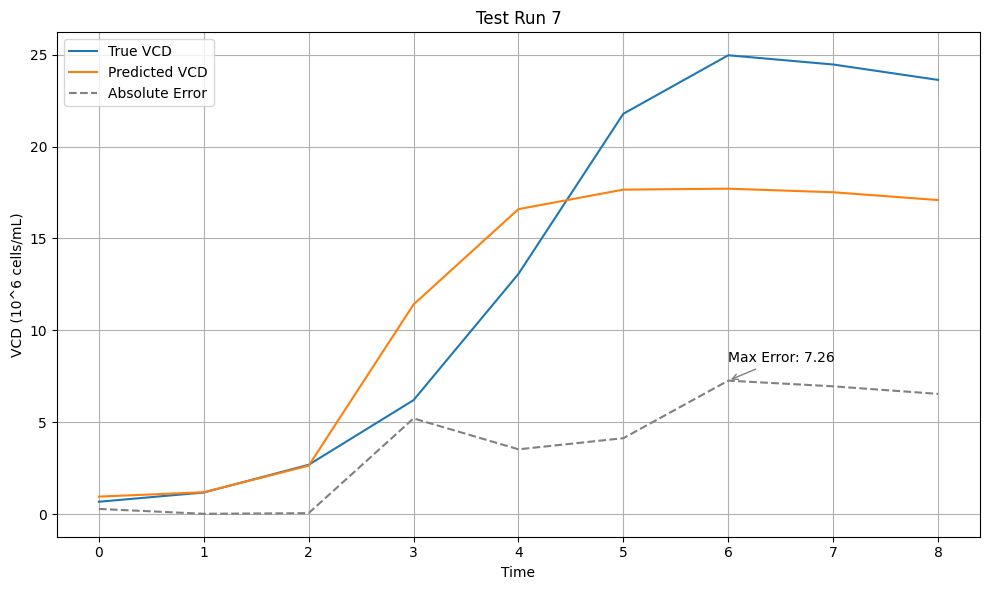

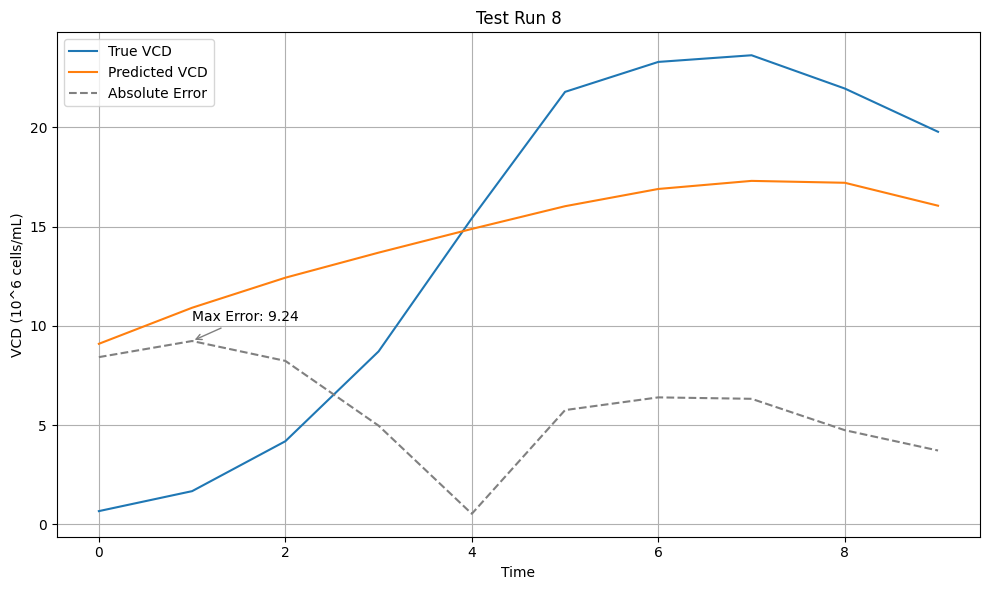

In [ ]:
for i in range(n_samples):
    mask = y_test[i] != -2.0
    time_points = np.arange(sum(mask))
    true_vals = vcd_true_original[i][mask]
    pred_vals = vcd_pred_original[i][mask]
    abs_error = np.abs(true_vals - pred_vals)

    plt.figure(figsize=(10, 6))
    plt.plot(time_points, true_vals, label='True VCD')
    plt.plot(time_points, pred_vals, label='Predicted VCD')
    plt.plot(time_points, abs_error, label='Absolute Error', color='gray', linestyle='--')

    plt.title(f'Test Run {i+1}')
    plt.xlabel('Time')
    plt.ylabel('VCD (10^6 cells/mL)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    max_idx = np.argmax(abs_error)
    plt.annotate(f"Max Error: {abs_error[max_idx]:.2f}",
             xy=(time_points[max_idx], abs_error[max_idx]),
             xytext=(time_points[max_idx], abs_error[max_idx] + 1),
             arrowprops=dict(arrowstyle="->", color='gray'))


In [ ]:
print("Model predictions at t=0 (scaled):")
print(predicted_vcd[:, 0])

Model predictions at t=0 (scaled):
[-0.9348926  -0.9351363  -0.93587244 -0.9340768  -0.9340105  -0.9352399
 -0.93248826 -0.33438227]


In [ ]:
print("True VCD at t=0 (scaled):")
print(y_test[:, 0])

True VCD at t=0 (scaled):
[-0.95602334 -0.95602334 -0.95602334 -0.94501084 -0.94501084 -0.95305794
 -0.95305794 -0.95305794]


In [ ]:
group = val_df.groupby(group_cols).first().reset_index()

errors = []
for i in range(len(vcd_true_original)):
    true_vals = vcd_true_original[i]
    pred_vals = vcd_pred_original[i]

    mask = true_vals > 0
    mae = mean_absolute_error(true_vals[mask], pred_vals[mask])
    rmse = np.sqrt(np.mean((true_vals[mask] - pred_vals[mask]) ** 2))

    errors.append({'group_index': i, 'MAE': mae, 'RMSE': rmse})

error_df = pd.DataFrame(errors)

group = group.reset_index(drop=True)
group_with_error = pd.concat([group, error_df], axis=1)

summary = group_with_error.groupby('group_volume')[['MAE', 'RMSE']].mean().sort_values('MAE')

print(summary)

                   MAE      RMSE
group_volume                    
3.0           0.939293  1.158132
200.0         1.053590  1.273068
500.0         1.938238  2.463588
2000.0        2.384920  2.982891


In [ ]:
model.save('my_model_improved.keras')
files.download('my_model_improved.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

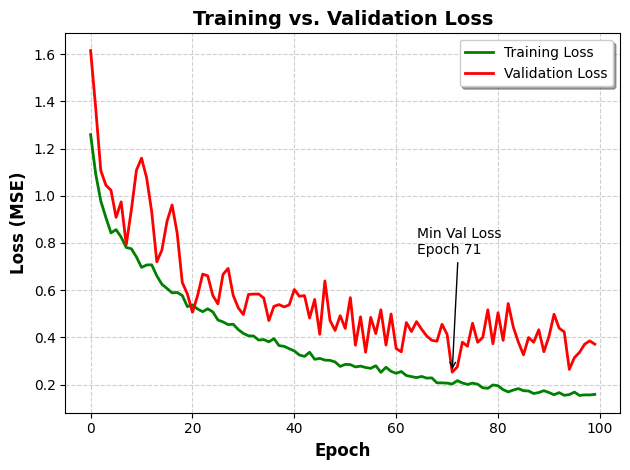

In [ ]:
plt.plot(history.history['loss'], label='Training Loss', linewidth=2, color= 'green')
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2, color = 'red')
plt.xlabel('Epoch', fontsize=12, fontweight='bold')
plt.ylabel('Loss (MSE)', fontsize=12, fontweight='bold')
plt.title('Training vs. Validation Loss', fontsize=14, fontweight='bold')
plt.legend(fontsize=10, frameon=True, shadow=True, loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

best_epoch = np.argmin(history.history['val_loss'])
best_val = history.history['val_loss'][best_epoch]
plt.annotate(f'Min Val Loss\nEpoch {best_epoch}',
             xy=(best_epoch, best_val),
             xytext=(best_epoch -7, best_val + 0.50),
             arrowprops=dict(facecolor='gray', arrowstyle='->'),
             fontsize=10)
plt.savefig("training_validation_loss_improved.png", dpi=300)

In [ ]:
files.download("training_validation_loss_improved.png")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>